# Model #

I try to put down a model. I will use the xor-perceptron model as a base and modify that.

first create the lattice, N by N, with Nsol = N**2

I should create a class for the cell object and then the network class is formed by cell objects and when the network is created, each network is associated with a position in the lattice.

Note: for now I'm only considering one possible link between each pair neuron for each direction

In [1]:
import numpy as np
from numpy import random as nrd
import matplotlib.pyplot as plt
import graph_tool as gt
from graph_tool.all import *
import copy

import model_ricard as m       # I've put all the functions in a separate Python file

In [2]:
# parameters of the simulation
par={'L': 4,                    # side length of the squared lattice
     'p_self_link': 0,         # probability for each cell of having a self link
     'C_density': 1,                       # initial density of links
     'J_range': [-1,+1],                       # define the possible value for J.
     'gamma': 2,                             # gamma parameter of the Boltzmann function (transfer function)
     'tau': 700,                                   # temperature parameter for the softmax 
     'T_crossover_ratio': 0,                    # percentage of offspring to be generated by crossover + mutation (instead of only mutation)
     'target_set': [-1.0,1.0,1.0,-1.0],
     'input_set':[[-1,-1],[-1,1],[1,-1],[1,1]],
     'majority_ratio': None,                       # output = np.mean(state[int(par['majority_ratio']*par['L']):-1]); if None, output = state[-1]
     'ff_iter': 6,                               # number of iterations the ff is executed for computing the output of a network (to reach the steady state)
     'J_mutation_radius': 0.05,                 # standard deviation of the normal distribution used to sample the mutation value for J.
     'B_mutation_radius': 0.05,            # standard deviation of the normal distribution used to sample the mutation value for B.
     'T_mutation_radius': 0.05,           # standard deviation of the normal distribution used to sample the mutation value for T.
     'reproduction_ratio': 0.7,          # percentage of offsprings to be generated by reproduction (the reamining by random generation)
     'elitist_ratio':0.2,
     #'x_n': np.linspace(-1,1,64),   # discretization of the input of the transfer function (last argmument 
                                   # is also the maximum number of non-zero coefficients in the DFT of the 
                                   # transfer function. it should be a power of 2 for best performance of fft)
     'n_iter': 1000,                    # number of iterations of the algorithm
     'N_sol': 200}                       # number of solutions (individuals, networks) considered in the simulation

if par['reproduction_ratio'] + par['elitist_ratio'] > 1:
     print(f'Error: expected sum of reproduction ratio and elitist ratio to be at maximum 1, but instead got {par[
          'reproduction_ratio']} + {par['elitist_ratio']} = {par['reproduction_ratio']+par['elitist_ratio']}')

#nrd.seed(1234)

In [3]:
solutions, lmean, t_dist_mean, volume_mean, loss_ev, mean_asp = m.evolution(par,verb=2,gen_verb=False,stat=True)

Iteration #0...
Mean loss: 1.0005700605012025
Best loss: 1.0
Cumulative Best loss: 1.0
Iteration #10...
Mean loss: 1.0003110074977621
Best loss: 0.999999999972198
Cumulative Best loss: 0.999999999972198
Iteration #20...
Mean loss: 1.0002685921376948
Best loss: 0.99999998757619
Cumulative Best loss: 0.999999999972198
Iteration #30...
Mean loss: 1.0003782394164427
Best loss: 0.99999998757619
Cumulative Best loss: 0.99999998757619
Iteration #40...
Mean loss: 1.0001832237372899
Best loss: 0.9999999837642652
Cumulative Best loss: 0.9999999837642652
Iteration #50...
Mean loss: 1.0003282043312596
Best loss: 0.9999999837642652
Cumulative Best loss: 0.9999999837642652
Iteration #60...
Mean loss: 1.0002709639124256
Best loss: 0.9999999744059833
Cumulative Best loss: 0.9999999744059833
Iteration #70...
Mean loss: 1.0002836124042498
Best loss: 0.9999998704956867
Cumulative Best loss: 0.9999999599519573
Iteration #80...
Mean loss: 1.000368140592619
Best loss: 0.9999998704956867
Cumulative Best loss

In [4]:
losses = []
for n,sol in enumerate(solutions[:10]):
    print(f'Solution #{n}')
    loss,_,_ = m.compute_loss(sol,par,verb=True)
    losses.append(loss)
    print(f'loss:{loss}')

Solution #0
Input: [-1, -1] -> Output: -0.9995808108313425
Target distance:1.7571955911973526e-07
Link cost:0.12027339585453051
Input: [-1, 1] -> Output: -0.9996584129347458
Target distance:3.9986337684207056
Link cost:0.12027339585453051
Input: [1, -1] -> Output: 0.9998987632418801
Target distance:1.0248881194628097e-08
Link cost:0.12027339585453051
Input: [1, 1] -> Output: -0.9985245108528544
Target distance:2.1770682233443616e-06
Link cost:0.12027339585453051
loss:0.9996590328643423
Solution #1
Input: [-1, -1] -> Output: -0.9998158834897535
Target distance:3.389888934535825e-08
Link cost:0.13248824398765285
Input: [-1, 1] -> Output: 0.9997999090814682
Target distance:4.003637567889634e-08
Link cost:0.13248824398765285
Input: [1, -1] -> Output: 0.9998125902942709
Target distance:3.5122397801452125e-08
Link cost:0.13248824398765285
Input: [1, 1] -> Output: -0.9998069777574621
Target distance:3.7257586114368125e-08
Link cost:0.13248824398765285
loss:3.657881223501871e-08
Solution #2
In

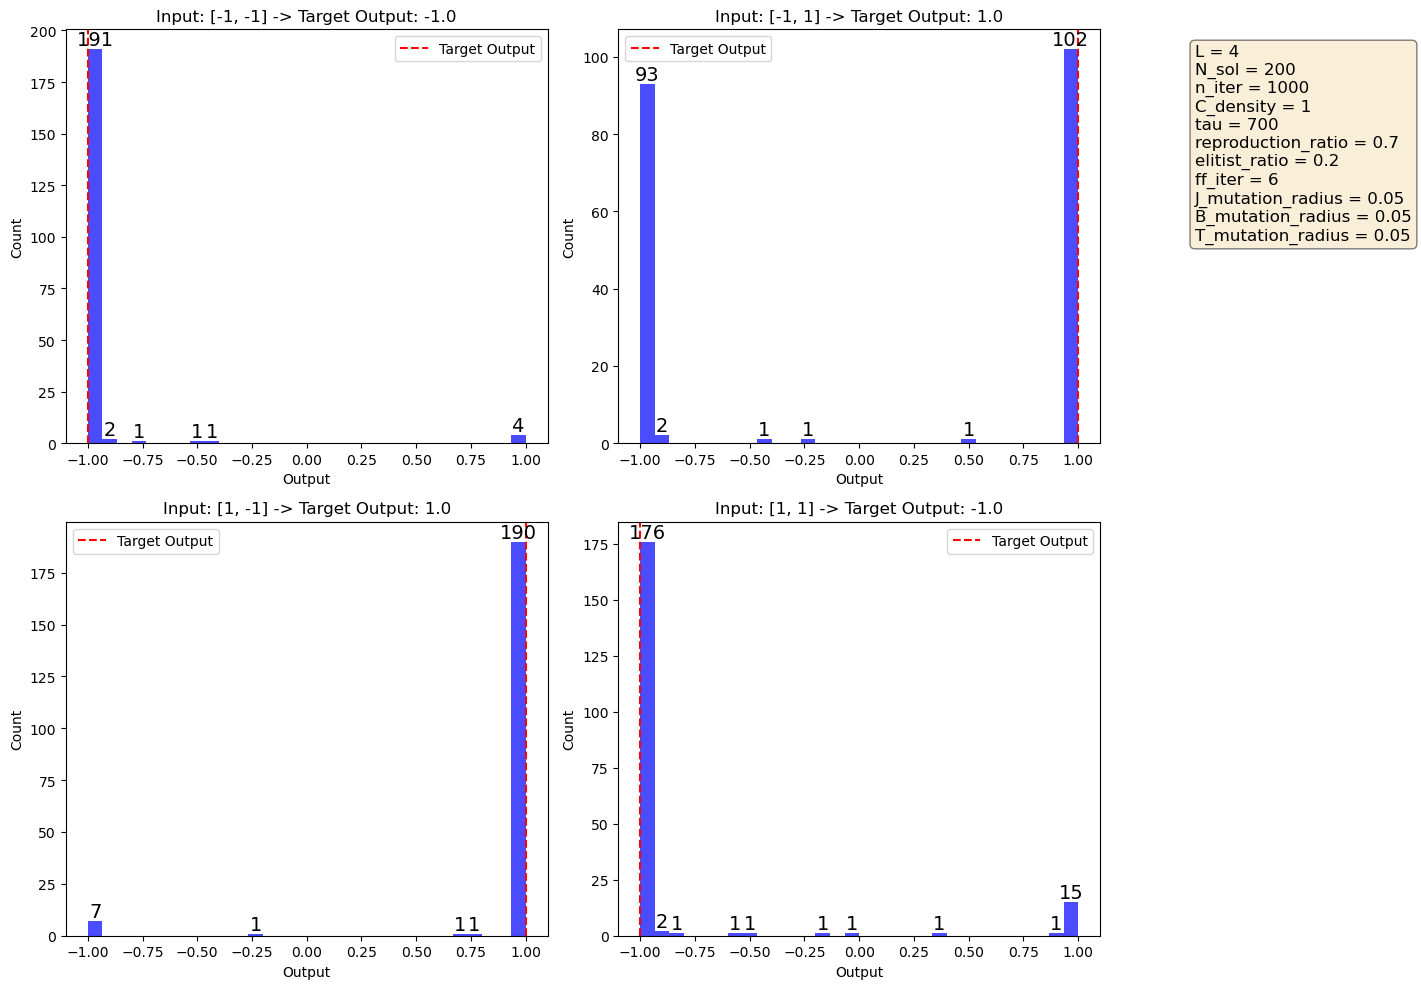

In [5]:
outputs = np.zeros((len(solutions), len(par['input_set'])))
for n, sol in enumerate(solutions):
    for i, input in enumerate(par['input_set']):
        output = m.ff(input, sol, par)
        outputs[n, i] = output

fig, axes = plt.subplots(2, len(par['input_set']) // 2, figsize=(16, 10))
axes = axes.flatten()
for i, ax in enumerate(axes):
    ax.hist(outputs[:, i], bins=30, alpha=0.7, color='b')
    ax.set_title(f'Input: {par["input_set"][i]} -> Target Output: {par["target_set"][i]}')
    ax.set_xlabel('Output')
    ax.set_ylabel('Count')
    ax.axvline(par['target_set'][i], label='Target Output', color='r', linestyle='--')
    for patch in ax.patches:
        height = patch.get_height()
        if height > 0:
            ax.annotate(f'{int(height)}',
                        (patch.get_x() + patch.get_width() / 2, height),
                        ha='center', va='bottom', fontsize=14)
    ax.legend()

# Prepare parameter text
param_text = (
    f"L = {par['L']}\n"
    f"N_sol = {par['N_sol']}\n"
    f"n_iter = {par['n_iter']}\n"
    f"C_density = {par['C_density']}\n"
    f"tau = {par['tau']}\n"
    f"reproduction_ratio = {par['reproduction_ratio']}\n"
    f"elitist_ratio = {par['elitist_ratio']}\n"
    f"ff_iter = {par['ff_iter']}\n"
    f"J_mutation_radius = {par['J_mutation_radius']}\n"
    f"B_mutation_radius = {par['B_mutation_radius']}\n"
    f"T_mutation_radius = {par['T_mutation_radius']}"
)

# Add parameter box
fig.text(0.75, 0.95, param_text, fontsize=12, va='top', ha='left',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout(rect=[0, 0, 0.7, 1])
plt.show()

Links density:0.19140625


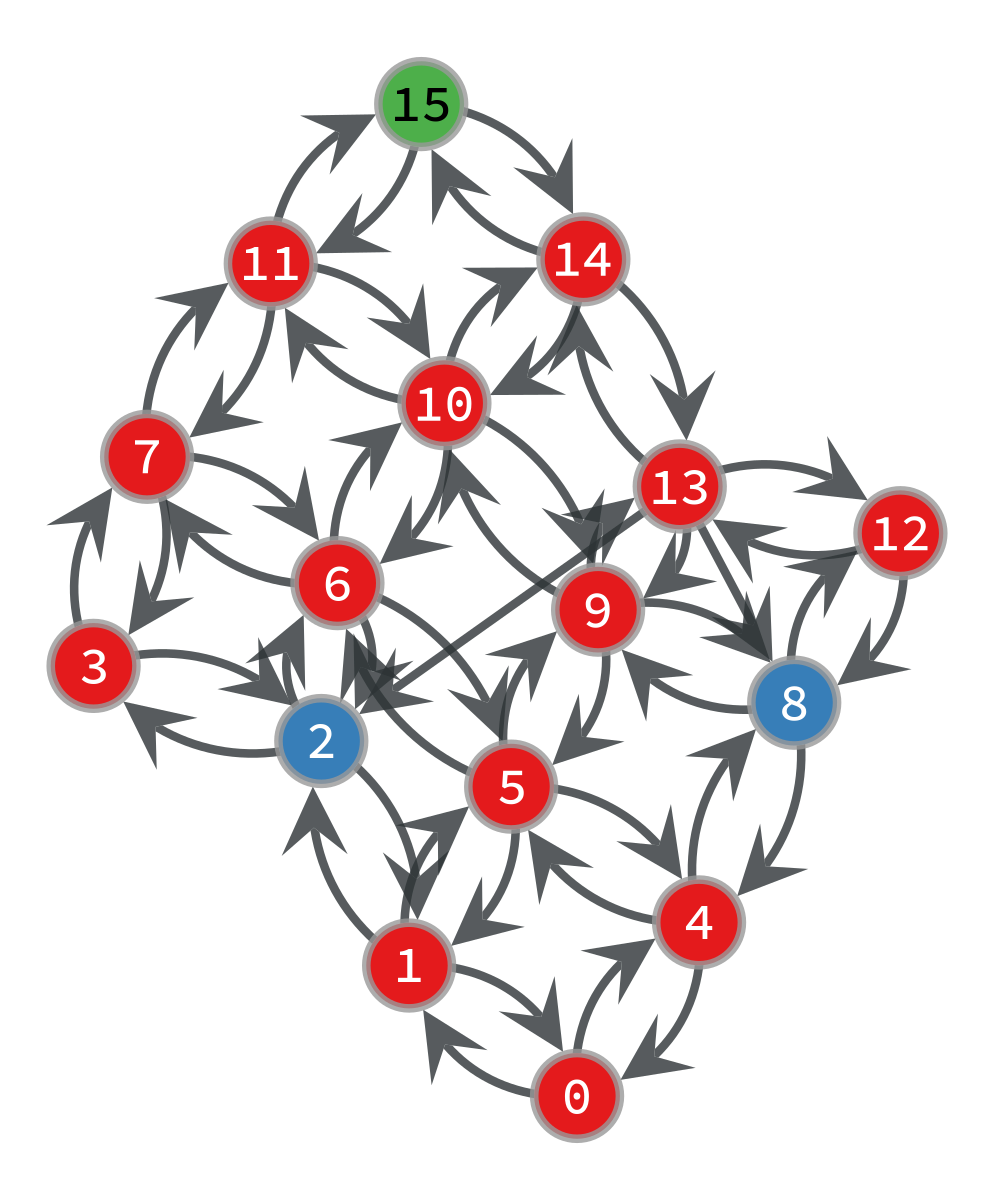

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x7fd4a51f9090, at 0x7fd4a51ed010>

In [6]:
print(f'Links density:{np.sum(solutions[0].C)/solutions[0].C.shape[0]**2}')

graph = solutions[1].G

highlight = graph.new_vertex_property('int')
highlight[graph.vertex(2)] = 1
highlight[graph.vertex(2*par['L'])] = 1
if par['majority_ratio'] is not None:
    for i in range(int(par['majority_ratio']*(par['L']**2)),graph.num_vertices()):  # outputs
        highlight[graph.vertex(i)] = 2
else: 
    highlight[graph.vertex(par['L']**2-1)] = 2

graph_draw(
    graph,
    vertex_text=graph.vertex_index,
    vertex_fill_color=highlight,
    vcmap=plt.cm.Set1
)

In [7]:
sol = sorted(solutions, key=lambda sol: sol.loss)
for i,input in enumerate(par['input_set']):
    output = m.ff(input,sol[0],par,verb=0)
    print(f'Input:{input} -> Output:{output} -- Expected:{par['target_set'][i]}')

Input:[-1, -1] -> Output:-0.9998607407261308 -- Expected:-1.0
Input:[-1, 1] -> Output:0.9998942732127947 -- Expected:1.0
Input:[1, -1] -> Output:0.9999357984345891 -- Expected:1.0
Input:[1, 1] -> Output:-0.9998818487989736 -- Expected:-1.0


Links density:0.1953125


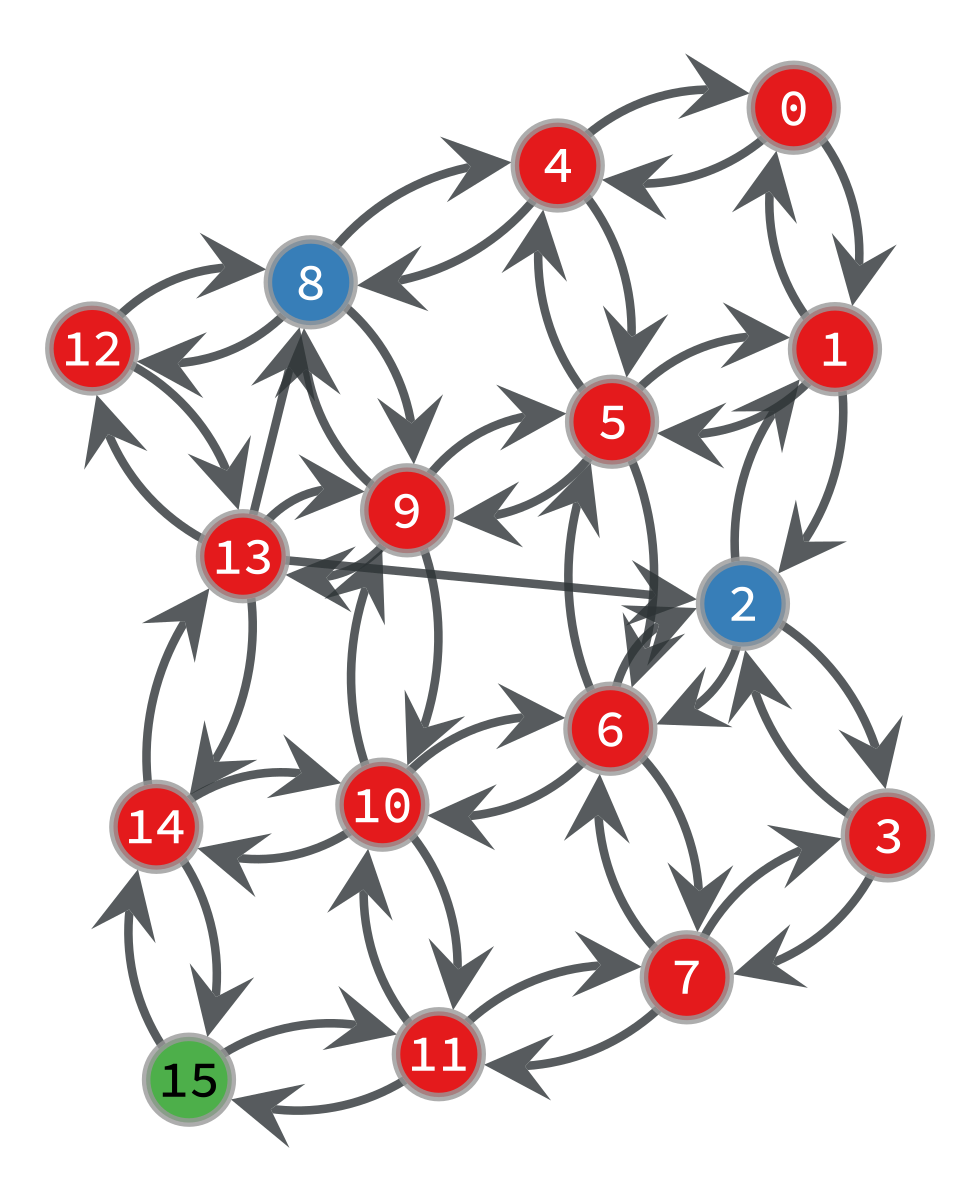

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x7fd4a665d310, at 0x7fd4a51ee900>

In [8]:
print(f'Links density:{np.sum(sol[0].C)/sol[0].C.shape[0]**2}')
graph = sol[0].G

highlight = graph.new_vertex_property('int')
highlight[graph.vertex(2)] = 1
highlight[graph.vertex(2*par['L'])] = 1
if par['majority_ratio'] is not None:
    for i in range(int(par['majority_ratio']*(par['L']**2)),graph.num_vertices()):  # outputs
        highlight[graph.vertex(i)] = 2
else: 
    highlight[graph.vertex(par['L']**2-1)] = 2

graph_draw(
    graph,
    vertex_text=graph.vertex_index,
    vertex_fill_color=highlight,
    vcmap=plt.cm.Set1
)

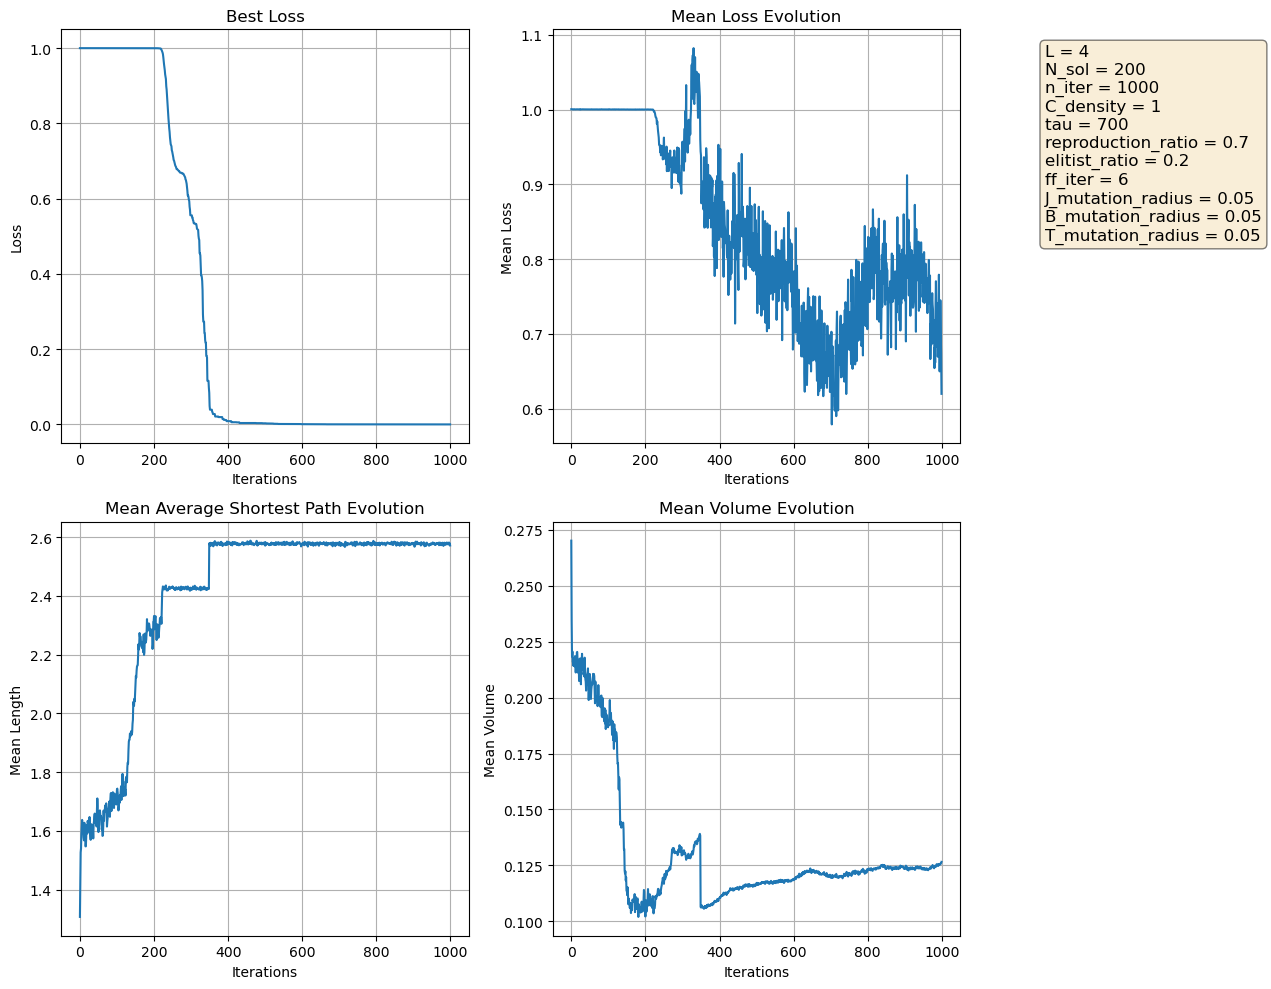

In [9]:
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# Best Loss
best_loss = np.min(loss_ev, axis=0)
axs[0, 0].plot(best_loss)
axs[0, 0].set_title('Best Loss')
axs[0, 0].set_xlabel('Iterations')
axs[0, 0].set_ylabel('Loss')
axs[0, 0].grid(True)

# Mean Loss Evolution
axs[0, 1].plot(np.arange(par['n_iter']), lmean)
axs[0, 1].set_title('Mean Loss Evolution')
axs[0, 1].set_xlabel('Iterations')
axs[0, 1].set_ylabel('Mean Loss')
#axs[0, 1].set_xscale('log')
axs[0, 1].grid(True)

# Mean Average Shortest Path Evolution
axs[1, 0].plot(mean_asp)
axs[1, 0].set_title('Mean Average Shortest Path Evolution')
axs[1, 0].set_xlabel('Iterations')
axs[1, 0].set_ylabel('Mean Length')
axs[1, 0].grid(True)

# Mean Volume Evolution
axs[1, 1].plot(volume_mean)
axs[1, 1].set_title('Mean Volume Evolution')
axs[1, 1].set_xlabel('Iterations')
axs[1, 1].set_ylabel('Mean Volume')
#axs[1, 1].set_xscale('log')
axs[1, 1].grid(True)

# Prepare parameter text
param_text = (
    f"L = {par['L']}\n"
    f"N_sol = {par['N_sol']}\n"
    f"n_iter = {par['n_iter']}\n"
    f"C_density = {par['C_density']}\n"
    f"tau = {par['tau']}\n"
    f"reproduction_ratio = {par['reproduction_ratio']}\n"
    f"elitist_ratio = {par['elitist_ratio']}\n"
    f"ff_iter = {par['ff_iter']}\n"
    f"J_mutation_radius = {par['J_mutation_radius']}\n"
    f"B_mutation_radius = {par['B_mutation_radius']}\n"
    f"T_mutation_radius = {par['T_mutation_radius']}"
)

# Add parameter box
fig.text(0.75, 0.95, param_text, fontsize=12, va='top', ha='left',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout(rect=[0, 0, 0.7, 1])
plt.savefig('plots/loss.png')
plt.show()
